In [ ]:
import torch

print("GPU available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

GPU available: True
Tesla T4


In [ ]:
%pip install -q lungmask==0.2.21 SimpleITK pandas matplotlib scikit-learn

from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import torch

PROJECT = Path("/content/drive/MyDrive/covid_ct_project")
PROJECT.mkdir(parents=True, exist_ok=True)

# Keep downloaded model weights between Colab sessions.
torch.hub.set_dir(str(PROJECT / "model_cache"))

print("Project folder:", PROJECT)
print("GPU:", torch.cuda.get_device_name(0))

In [ ]:
import requests
import pandas as pd
from tqdm.auto import tqdm

BASE = "https://stoic2021-training.s3.amazonaws.com"
SCAN_DIR = PROJECT / "scans"
SCAN_DIR.mkdir(exist_ok=True)

def download_file(url, destination):
    with requests.get(url, stream=True, timeout=(30, 120)) as response:
        response.raise_for_status()
        expected = int(response.headers.get("Content-Length", 0))

        if (
            destination.exists()
            and expected > 0
            and destination.stat().st_size == expected
        ):
            print(f"Already downloaded: {destination.name}")
            return

        temporary = destination.with_suffix(destination.suffix + ".part")
        with temporary.open("wb") as output, tqdm(
            total=expected or None,
            unit="B",
            unit_scale=True,
            desc=destination.name,
        ) as progress:
            for chunk in response.iter_content(chunk_size=1024 * 1024):
                if chunk:
                    output.write(chunk)
                    progress.update(len(chunk))

        if expected and temporary.stat().st_size != expected:
            raise RuntimeError(f"Incomplete download: {destination.name}")

        temporary.replace(destination)

download_file(
    f"{BASE}/metadata/reference.csv",
    PROJECT / "reference.csv",
)
download_file(
    f"{BASE}/LICENCE.txt",
    PROJECT / "LICENCE.txt",
)

labels = pd.read_csv(PROJECT / "reference.csv")

for patient_id in [8622, 1173]:
    download_file(
        f"{BASE}/data/mha/{patient_id}.mha",
        SCAN_DIR / f"{patient_id}.mha",
    )

display(labels[labels["PatientID"].isin([8622, 1173])])

In [ ]:
import numpy as np
import SimpleITK as sitk
import torch
from lungmask import LMInferer

assert torch.cuda.is_available(), "Enable a GPU before running."

MASK_DIR = PROJECT / "masks"
MASK_DIR.mkdir(exist_ok=True)

# Small batches keep GPU memory usage manageable.
segmenter = LMInferer(
    modelname="R231",
    batch_size=4,
    force_cpu=False,
)

for patient_id in [8622, 1173]:
    scan_path = SCAN_DIR / f"{patient_id}.mha"
    mask_path = MASK_DIR / f"{patient_id}_lung_mask.mha"

    if mask_path.exists():
        print(f"Mask already saved: {patient_id}")
        continue

    print(f"Segmenting patient {patient_id}...")
    scan = sitk.ReadImage(str(scan_path))
    prediction = segmenter.apply(scan)

    # Combine the left and right lung labels into one lung mask.
    mask = sitk.GetImageFromArray(
        (prediction > 0).astype(np.uint8)
    )
    mask.CopyInformation(scan)

    # Save through a temporary file to avoid accepting partial outputs.
    temporary = MASK_DIR / f"{patient_id}_lung_mask.part.mha"
    sitk.WriteImage(mask, str(temporary), True)
    temporary.replace(mask_path)

    print(f"Saved: {mask_path.name}")

print("Both sample masks are ready.")

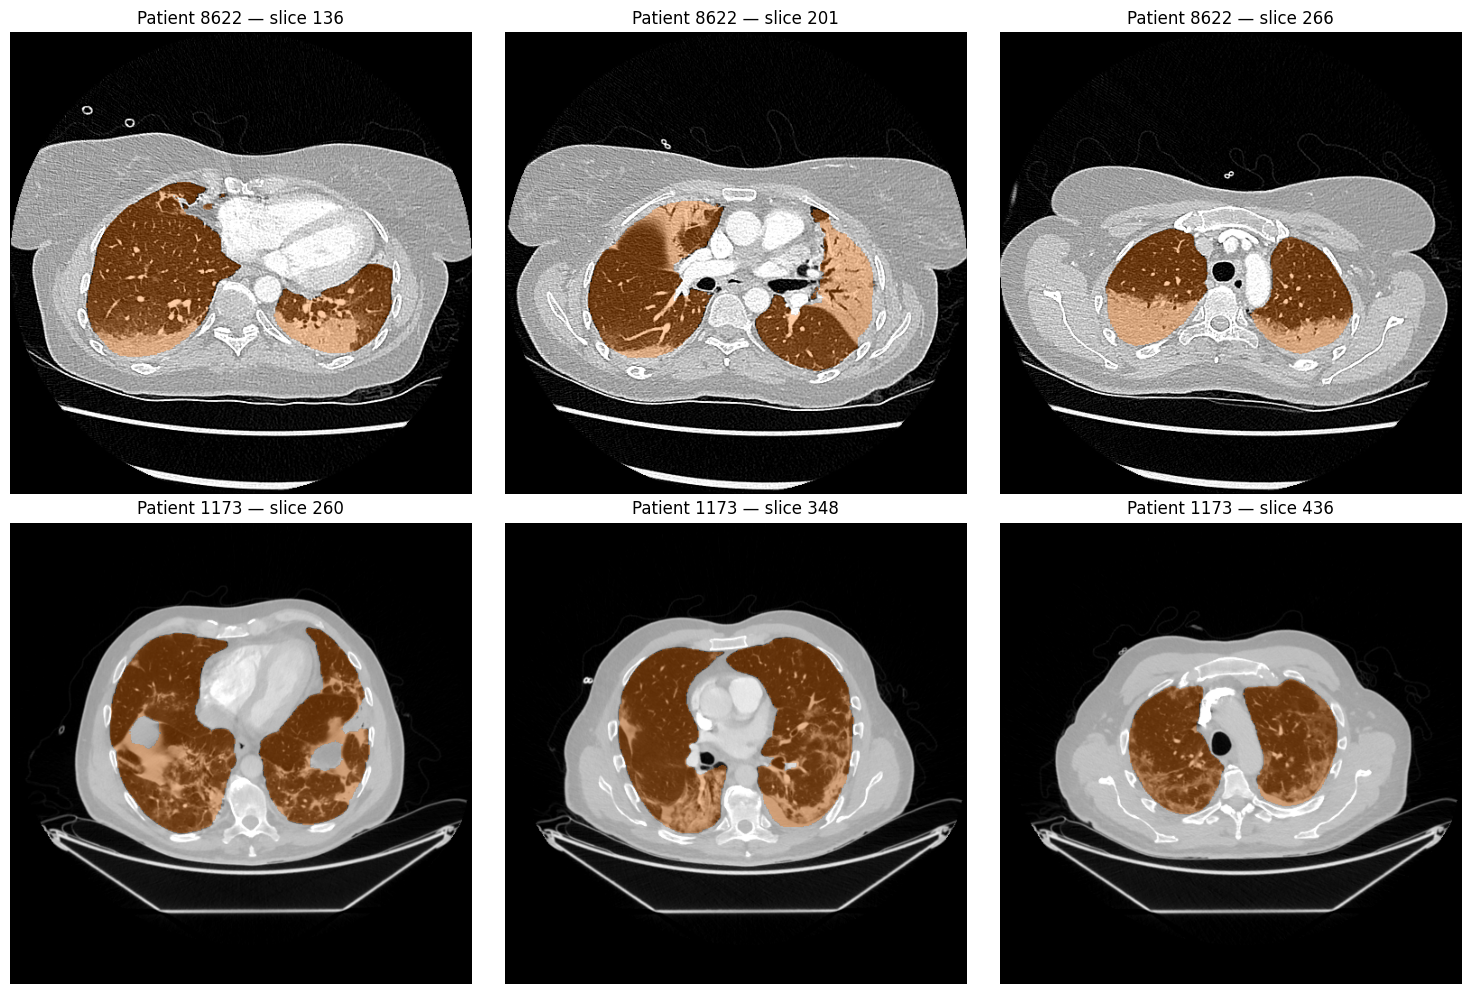

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for row, patient_id in enumerate([8622, 1173]):
    scan = sitk.ReadImage(str(SCAN_DIR / f"{patient_id}.mha"))
    mask = sitk.ReadImage(
        str(MASK_DIR / f"{patient_id}_lung_mask.mha")
    )

    image = sitk.GetArrayFromImage(scan)
    lung = sitk.GetArrayFromImage(mask).astype(bool)

    assert image.shape == lung.shape, "Scan and mask dimensions differ."
    lung_slices = np.flatnonzero(lung.any(axis=(1, 2)))
    assert len(lung_slices) > 0, f"Empty mask for {patient_id}"

    for col, fraction in enumerate([0.25, 0.5, 0.75]):
        z = lung_slices[round((len(lung_slices) - 1) * fraction)]
        ax = axes[row, col]

        ax.imshow(image[z], cmap="gray", vmin=-1000, vmax=400)
        overlay = np.zeros((*lung[z].shape, 4))
        overlay[lung[z]] = [1.0, 0.45, 0.0, 0.35]
        ax.imshow(overlay)

        ax.set_title(f"Patient {patient_id} — slice {z}")
        ax.axis("off")

plt.tight_layout()
plt.savefig(PROJECT / "sample_mask_check.png", dpi=150)
plt.show()

In [ ]:
import pandas as pd

feature_rows = []

for patient_id in [8622, 1173]:
    scan = sitk.ReadImage(str(SCAN_DIR / f"{patient_id}.mha"))
    mask = sitk.ReadImage(
        str(MASK_DIR / f"{patient_id}_lung_mask.mha")
    )

    image = sitk.GetArrayFromImage(scan)
    lung = sitk.GetArrayFromImage(mask).astype(bool)

    assert image.shape == lung.shape
    assert lung.any(), f"Empty mask for {patient_id}"

    # Fixed intensity range for this initial feature-extraction trial.
    values = np.clip(image[lung].astype(np.float64), -1000, 400)

    histogram, _ = np.histogram(
        values, bins=56, range=(-1000, 400)
    )
    probabilities = histogram[histogram > 0] / histogram.sum()

    patient_label = labels.loc[
        labels["PatientID"] == patient_id, "probSevere"
    ]
    assert len(patient_label) == 1

    feature_rows.append({
        "patient_id": patient_id,
        "lung_volume_ml": (
            lung.sum() * np.prod(scan.GetSpacing()) / 1000
        ),
        "mean_intensity": values.mean(),
        "std_intensity": values.std(),
        "p10_intensity": np.percentile(values, 10),
        "median_intensity": np.median(values),
        "p90_intensity": np.percentile(values, 90),
        "histogram_entropy": -np.sum(
            probabilities * np.log2(probabilities)
        ),
        "severe": int(patient_label.iloc[0]),
    })

features = pd.DataFrame(feature_rows)
features.to_csv(PROJECT / "sample_features.csv", index=False)

display(features.round(3))
print("Saved sample_features.csv")

,patient_id,lung_volume_ml,mean_intensity,std_intensity,p10_intensity,median_intensity,p90_intensity,histogram_entropy,severe
0,8622,1950.329,-558.829,405.172,-954.0,-729.0,116.0,5.319,0
1,1173,4014.049,-684.811,269.727,-912.0,-803.0,-239.0,4.754,1


Saved sample_features.csv


In [ ]:
from scipy.ndimage import zoom

def texture_features(image, lung, spacing_xyz):
    # Standardize in-plane spacing to 1 mm for this 2D texture baseline.
    sx, sy, _ = spacing_xyz
    matrix = np.zeros((32, 32), dtype=np.float64)

    for z in np.flatnonzero(lung.any(axis=(1, 2))):
        img = zoom(
            image[z].astype(np.float32),
            (sy, sx),
            order=1,
        )
        region = zoom(
            lung[z].astype(np.uint8),
            (sy, sx),
            order=0,
        ).astype(bool)

        # Fixed 32 intensity bins spanning -1000 to 400.
        quantized = np.floor(
            (np.clip(img, -1000, 400) + 1000) / 1400 * 32
        ).astype(np.int32)
        quantized = np.clip(quantized, 0, 31)

        for axis in [0, 1]:
            if axis == 0:
                a, b = quantized[:-1, :], quantized[1:, :]
                valid = region[:-1, :] & region[1:, :]
            else:
                a, b = quantized[:, :-1], quantized[:, 1:]
                valid = region[:, :-1] & region[:, 1:]

            counts = np.bincount(
                a[valid] * 32 + b[valid],
                minlength=32 * 32,
            ).reshape(32, 32)

            matrix += counts + counts.T

    assert matrix.sum() > 0, "No valid lung pixel pairs."
    p = matrix / matrix.sum()
    i, j = np.indices(p.shape)
    nonzero = p[p > 0]

    return {
        "texture_contrast": np.sum(p * (i - j) ** 2),
        "texture_homogeneity": np.sum(p / (1 + (i - j) ** 2)),
        "texture_energy": np.sum(p ** 2),
        "texture_entropy": -np.sum(nonzero * np.log2(nonzero)),
    }

for patient_id in [8622, 1173]:
    scan = sitk.ReadImage(str(SCAN_DIR / f"{patient_id}.mha"))
    mask = sitk.ReadImage(
        str(MASK_DIR / f"{patient_id}_lung_mask.mha")
    )

    texture = texture_features(
        sitk.GetArrayFromImage(scan),
        sitk.GetArrayFromImage(mask).astype(bool),
        scan.GetSpacing(),
    )

    for name, value in texture.items():
        features.loc[
            features["patient_id"] == patient_id, name
        ] = value

features.to_csv(PROJECT / "sample_features.csv", index=False)
display(features.round(3))

,patient_id,lung_volume_ml,mean_intensity,std_intensity,p10_intensity,median_intensity,p90_intensity,histogram_entropy,severe,texture_contrast,texture_homogeneity,texture_energy,texture_entropy
0,8622,1950.329,-558.829,405.172,-954.0,-729.0,116.0,5.319,0,24.705,0.331,0.007,8.203
1,1173,4014.049,-684.811,269.727,-912.0,-803.0,-239.0,4.754,1,4.387,0.607,0.038,6.415


In [ ]:
covid_positive = labels[
    (labels["probCOVID"] == 1)
    & (~labels["PatientID"].isin([8622, 1173]))
].copy()

batch = pd.concat([
    covid_positive[covid_positive["probSevere"] == 0]
        .sample(n=75, random_state=42),
    covid_positive[covid_positive["probSevere"] == 1]
        .sample(n=25, random_state=42),
]).sample(frac=1, random_state=42).reset_index(drop=True)

batch.to_csv(PROJECT / "batch_manifest.csv", index=False)

print("Selected patients:", len(batch))
print(batch["probSevere"].value_counts())
display(batch.head())

Selected patients: 100
probSevere
0    75
1    25
Name: count, dtype: int64


,PatientID,probCOVID,probSevere
0,1868,1,1
1,5407,1,0
2,1399,1,0
3,4585,1,0
4,1068,1,0


In [ ]:
import time

OUTPUT = PROJECT / "cohort_features.csv"

if OUTPUT.exists():
    cohort = pd.read_csv(OUTPUT)
else:
    cohort = pd.DataFrame()

completed = (
    set(cohort["patient_id"].astype(int))
    if not cohort.empty else set()
)

pending = batch[
    ~batch["PatientID"].isin(completed)
]

started = time.time()

for _, patient in pending.iterrows():
    patient_id = int(patient["PatientID"])
    scan_path = SCAN_DIR / f"{patient_id}.mha"
    mask_path = MASK_DIR / f"{patient_id}_lung_mask.mha"

    print(f"\nProcessing patient {patient_id}")

    download_file(
        f"{BASE}/data/mha/{patient_id}.mha",
        scan_path,
    )
    scan = sitk.ReadImage(str(scan_path))

    if not mask_path.exists():
        prediction = segmenter.apply(scan)
        mask = sitk.GetImageFromArray(
            (prediction > 0).astype(np.uint8)
        )
        mask.CopyInformation(scan)

        temporary = MASK_DIR / f"{patient_id}_lung_mask.part.mha"
        sitk.WriteImage(mask, str(temporary), True)
        temporary.replace(mask_path)
    else:
        mask = sitk.ReadImage(str(mask_path))

    image = sitk.GetArrayFromImage(scan)
    lung = sitk.GetArrayFromImage(mask).astype(bool)

    assert image.shape == lung.shape
    assert np.allclose(scan.GetSpacing(), mask.GetSpacing())
    assert np.allclose(scan.GetOrigin(), mask.GetOrigin())
    assert np.allclose(scan.GetDirection(), mask.GetDirection())
    assert lung.any(), f"Empty mask for {patient_id}"

    values = np.clip(image[lung].astype(np.float64), -1000, 400)
    histogram, _ = np.histogram(
        values, bins=56, range=(-1000, 400)
    )
    probabilities = histogram[histogram > 0] / histogram.sum()

    record = {
        "patient_id": patient_id,
        "lung_volume_ml": (
            lung.sum() * np.prod(scan.GetSpacing()) / 1000
        ),
        "mean_intensity": values.mean(),
        "std_intensity": values.std(),
        "p10_intensity": np.percentile(values, 10),
        "median_intensity": np.median(values),
        "p90_intensity": np.percentile(values, 90),
        "histogram_entropy": -np.sum(
            probabilities * np.log2(probabilities)
        ),
        "severe": int(patient["probSevere"]),
    }

    record.update(
        texture_features(image, lung, scan.GetSpacing())
    )

    cohort = pd.concat(
        [cohort, pd.DataFrame([record])],
        ignore_index=True,
    )

    temporary_csv = OUTPUT.with_suffix(".tmp.csv")
    cohort.to_csv(temporary_csv, index=False)
    temporary_csv.replace(OUTPUT)

    del image, lung, values, scan, mask
    if "prediction" in locals():
        del prediction
    torch.cuda.empty_cache()

    print(f"Saved features for {patient_id}")

elapsed = time.time() - started
print(f"\nCompleted {len(pending)} patients in {elapsed / 60:.1f} minutes.")
if len(pending):
    print(f"Average: {elapsed / len(pending):.1f} seconds per patient.")
print(f"Total saved patients: {len(cohort)}")

In [ ]:
cohort = pd.read_csv(PROJECT / "cohort_features.csv")

print("Patient records:", len(cohort))
print("Duplicate patient IDs:", cohort["patient_id"].duplicated().sum())
print("\nOutcome counts (0 = non-severe, 1 = severe):")
print(cohort["severe"].value_counts().sort_index())

predictors = cohort.drop(columns=["patient_id", "severe"])

print("\nMissing feature values:", predictors.isna().sum().sum())
print(
    "Infinite feature values:",
    np.isinf(predictors.to_numpy(dtype=float)).sum(),
)

display(cohort.head())
display(cohort[["lung_volume_ml"]].describe())

Patient records: 100
Duplicate patient IDs: 0

Outcome counts (0 = non-severe, 1 = severe):
severe
0    75
1    25
Name: count, dtype: int64

Missing feature values: 0
Infinite feature values: 0


,patient_id,lung_volume_ml,mean_intensity,std_intensity,p10_intensity,median_intensity,p90_intensity,histogram_entropy,severe,texture_contrast,texture_homogeneity,texture_energy,texture_entropy
0,1868,2168.637197,-354.357102,327.581250,-789.0,-335.0,59.0,5.537684,1,10.372070,0.364190,0.005486,8.082973
1,5407,4196.368871,-781.132942,185.361867,-913.0,-840.0,-566.0,4.097525,0,5.148509,0.585731,0.050177,5.656341
2,1399,3751.473080,-727.549457,196.427836,-877.0,-790.0,-472.0,4.305457,0,5.718110,0.566853,0.038395,6.010243
3,4585,4594.555884,-846.856048,170.665215,-959.0,-889.0,-736.0,3.775658,0,7.669034,0.562442,0.062115,5.256602
4,1068,3020.210246,-611.187952,245.627670,-824.0,-711.0,-175.0,4.730031,0,3.586879,0.603642,0.029368,6.375325


,lung_volume_ml
count,100.000000
mean,3515.612490
std,1127.364245
min,1533.067715
25%,2667.794955
50%,3360.106150
75%,4211.779440
max,6752.761919


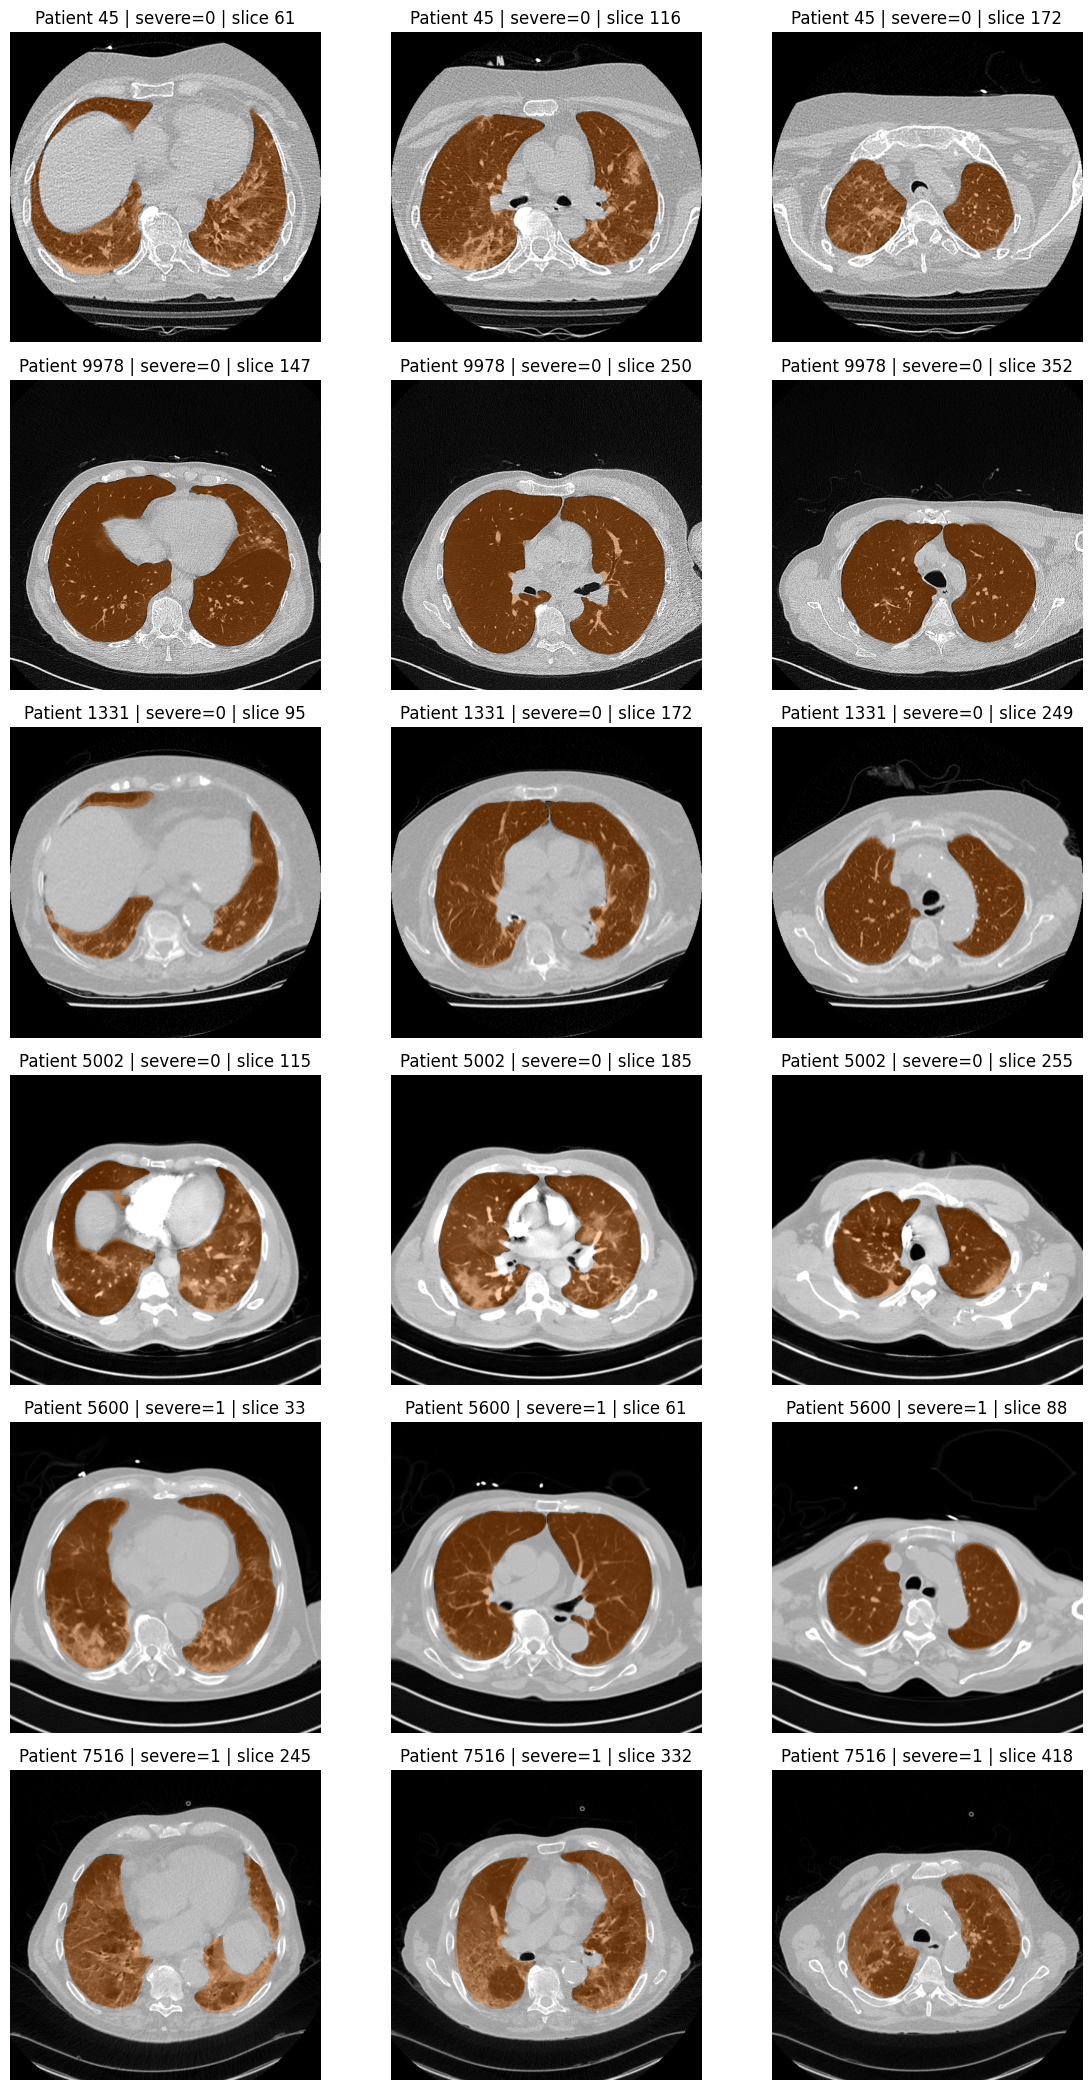

In [ ]:
review_ids = list(dict.fromkeys(
    [
        int(cohort.loc[cohort["lung_volume_ml"].idxmin(), "patient_id"]),
        int(cohort.loc[cohort["lung_volume_ml"].idxmax(), "patient_id"]),
    ]
    + cohort[cohort["severe"] == 0]
        .sample(2, random_state=42)["patient_id"].astype(int).tolist()
    + cohort[cohort["severe"] == 1]
        .sample(2, random_state=42)["patient_id"].astype(int).tolist()
))

fig, axes = plt.subplots(
    len(review_ids), 3,
    figsize=(12, 3.5 * len(review_ids)),
    squeeze=False,
)

for row, patient_id in enumerate(review_ids):
    scan = sitk.ReadImage(str(SCAN_DIR / f"{patient_id}.mha"))
    mask = sitk.ReadImage(
        str(MASK_DIR / f"{patient_id}_lung_mask.mha")
    )

    image = sitk.GetArrayFromImage(scan)
    lung = sitk.GetArrayFromImage(mask).astype(bool)
    slices = np.flatnonzero(lung.any(axis=(1, 2)))

    outcome = int(
        cohort.loc[cohort["patient_id"] == patient_id, "severe"].iloc[0]
    )

    for col, fraction in enumerate([0.25, 0.5, 0.75]):
        z = slices[round((len(slices) - 1) * fraction)]
        ax = axes[row, col]
        ax.imshow(image[z], cmap="gray", vmin=-1000, vmax=400)

        overlay = np.zeros((*lung[z].shape, 4))
        overlay[lung[z]] = [1, 0.45, 0, 0.35]
        ax.imshow(overlay)

        ax.set_title(f"Patient {patient_id} | severe={outcome} | slice {z}")
        ax.axis("off")

plt.tight_layout()
plt.savefig(PROJECT / "cohort_mask_review.png", dpi=120)
plt.show()

In [ ]:
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score,
    balanced_accuracy_score
)
import json
import joblib

cohort = pd.read_csv(PROJECT / "cohort_features.csv")

# IDs and outcome labels must not be used as predictors.
feature_columns = [
    col for col in cohort.columns
    if col not in ["patient_id", "severe"]
]
X = cohort[feature_columns]
y = cohort["severe"].astype(int)

train_indices, test_indices = train_test_split(
    cohort.index,
    test_size=0.20,
    stratify=y,
    random_state=42,
)

X_train, X_test = X.loc[train_indices], X.loc[test_indices]
y_train, y_test = y.loc[train_indices], y.loc[test_indices]

model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        C=1.0,
        class_weight="balanced",
        max_iter=2000,
        random_state=42,
    )),
])

# Scaling is fitted separately inside each training fold.
cv = StratifiedKFold(
    n_splits=5, shuffle=True, random_state=42
)
cv_results = cross_validate(
    model,
    X_train,
    y_train,
    cv=cv,
    scoring={
        "roc_auc": "roc_auc",
        "average_precision": "average_precision",
        "balanced_accuracy": "balanced_accuracy",
    },
)

print("TRAINING CROSS-VALIDATION")
for metric in ["roc_auc", "average_precision", "balanced_accuracy"]:
    scores = cv_results[f"test_{metric}"]
    print(f"{metric}: {scores.mean():.3f} ± {scores.std():.3f}")
print("(± is variation across folds, not a confidence interval.)")

# Fit once on all training patients, then evaluate the held-out test set.
model.fit(X_train, y_train)

probabilities = model.predict_proba(X_test)[:, 1]
predictions = (probabilities >= 0.5).astype(int)

test_metrics = {
    "roc_auc": float(roc_auc_score(y_test, probabilities)),
    "average_precision": float(
        average_precision_score(y_test, probabilities)
    ),
    "balanced_accuracy": float(
        balanced_accuracy_score(y_test, predictions)
    ),
}

print("\nHELD-OUT TEST RESULTS")
for metric, value in test_metrics.items():
    print(f"{metric}: {value:.3f}")

print("\n", classification_report(
    y_test,
    predictions,
    labels=[0, 1],
    target_names=["Non-severe", "Severe"],
    zero_division=0,
))
print("Confusion matrix: rows=actual, columns=predicted")
print(confusion_matrix(y_test, predictions, labels=[0, 1]))

test_predictions = pd.DataFrame({
    "patient_id": cohort.loc[test_indices, "patient_id"].to_numpy(),
    "actual_severe": y_test.to_numpy(),
    "severity_score": probabilities,
    "predicted_severe": predictions,
})
test_predictions.to_csv(PROJECT / "test_predictions.csv", index=False)

split_table = cohort[["patient_id", "severe"]].copy()
split_table["split"] = "train"
split_table.loc[test_indices, "split"] = "test"
split_table.to_csv(PROJECT / "patient_split.csv", index=False)

joblib.dump(
    {"pipeline": model, "feature_columns": feature_columns},
    PROJECT / "severity_model.joblib",
)

results = {
    "test": test_metrics,
    "training_cv": {
        metric: {
            "mean": float(cv_results[f"test_{metric}"].mean()),
            "std": float(cv_results[f"test_{metric}"].std()),
        }
        for metric in [
            "roc_auc", "average_precision", "balanced_accuracy"
        ]
    },
    "threshold": 0.5,
    "train_patients": len(train_indices),
    "test_patients": len(test_indices),
}
(PROJECT / "model_results.json").write_text(
    json.dumps(results, indent=2)
)

print("\nModel, patient split, predictions, and metrics saved.")

TRAINING CROSS-VALIDATION
roc_auc: 0.646 ± 0.188
average_precision: 0.515 ± 0.201
balanced_accuracy: 0.642 ± 0.090
(± is variation across folds, not a confidence interval.)

HELD-OUT TEST RESULTS
roc_auc: 0.733
average_precision: 0.645
balanced_accuracy: 0.567

               precision    recall  f1-score   support

  Non-severe       0.79      0.73      0.76        15
      Severe       0.33      0.40      0.36         5

    accuracy                           0.65        20
   macro avg       0.56      0.57      0.56        20
weighted avg       0.67      0.65      0.66        20

Confusion matrix: rows=actual, columns=predicted
[[11  4]
 [ 3  2]]

Model, patient split, predictions, and metrics saved.


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import pandas as pd
import joblib
import json

from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

PROJECT = Path("/content/drive/MyDrive/covid_ct_project")

# Restore the saved data and original split.
cohort = pd.read_csv(PROJECT / "cohort_features.csv")
split = pd.read_csv(PROJECT / "patient_split.csv")

data = cohort.merge(
    split[["patient_id", "split"]],
    on="patient_id",
    validate="one_to_one"
)

feature_columns = [
    col for col in cohort.columns
    if col not in ["patient_id", "severe"]
]

train = data.loc[data["split"] == "train"]
X_train = train[feature_columns]
y_train = train["severe"].astype(int)

assert len(train) == 80, "Expected the original 80 training patients."

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        max_iter=5000,
        random_state=42
    ))
])

# C controls how strongly the model limits large coefficients.
parameters = {
    "classifier__C": [0.001, 0.01, 0.1, 1.0, 10.0],
    "classifier__class_weight": [None, "balanced"]
}

cv = StratifiedKFold(
    n_splits=5, shuffle=True, random_state=42
)

search = GridSearchCV(
    pipeline,
    param_grid=parameters,
    scoring={
        "balanced_accuracy": "balanced_accuracy",
        "roc_auc": "roc_auc",
        "severe_recall": "recall"
    },
    refit="balanced_accuracy",
    cv=cv,
    n_jobs=2,
    error_score="raise"
)

search.fit(X_train, y_train)

results = pd.DataFrame(search.cv_results_)
results.to_csv(PROJECT / "tuning_results.csv", index=False)

print("Best settings:", search.best_params_)
print("\nTRAINING CROSS-VALIDATION — SELECTED SETTINGS")

best_index = search.best_index_
for metric in ["balanced_accuracy", "roc_auc", "severe_recall"]:
    mean = results.loc[best_index, f"mean_test_{metric}"]
    std = results.loc[best_index, f"std_test_{metric}"]
    print(f"{metric}: {mean:.3f} ± {std:.3f}")

# GridSearchCV already retrained this model on all 80 training patients.
joblib.dump(
    {
        "pipeline": search.best_estimator_,
        "feature_columns": feature_columns
    },
    PROJECT / "severity_model_tuned.joblib"
)

(PROJECT / "tuning_summary.json").write_text(
    json.dumps({
        "best_parameters": search.best_params_,
        "selection_metric": "balanced_accuracy",
        "training_patients": len(train)
    }, indent=2)
)

print("\nTuned model saved. Test patients were not used.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Best settings: {'classifier__C': 0.1, 'classifier__class_weight': 'balanced'}

TRAINING CROSS-VALIDATION — SELECTED SETTINGS
balanced_accuracy: 0.717 ± 0.133
roc_auc: 0.742 ± 0.200
severe_recall: 0.700 ± 0.292

Tuned model saved. Test patients were not used.


In [ ]:
import pandas as pd

labels = pd.read_csv(PROJECT / "reference.csv")
cohort = pd.read_csv(PROJECT / "cohort_features.csv")

manifest_path = PROJECT / "evaluation_manifest.csv"

if manifest_path.exists():
    evaluation = pd.read_csv(manifest_path)
else:
    excluded_ids = set(cohort["patient_id"].astype(int))
    excluded_ids.update([8622, 1173])  # Earlier demonstration patients

    eligible = labels[
        (labels["probCOVID"] == 1) &
        (~labels["PatientID"].isin(excluded_ids))
    ]

    evaluation = pd.concat([
        eligible[eligible["probSevere"] == 0].sample(
            n=30, random_state=2026
        ),
        eligible[eligible["probSevere"] == 1].sample(
            n=10, random_state=2026
        )
    ]).sample(frac=1, random_state=2026).reset_index(drop=True)

    evaluation.to_csv(manifest_path, index=False)

assert len(evaluation) == 40
assert evaluation["PatientID"].is_unique
assert not set(evaluation["PatientID"]) & set(cohort["patient_id"])
assert not evaluation["PatientID"].isin([8622, 1173]).any()
assert (evaluation["probCOVID"] == 1).all()
assert evaluation["probSevere"].value_counts().to_dict() == {0: 30, 1: 10}

print("New evaluation patients:", len(evaluation))
print("Outcome counts:")
print(evaluation["probSevere"].value_counts().sort_index())
print("\nSelection saved. No scans downloaded yet.")

New evaluation patients: 40
Outcome counts:
probSevere
0    30
1    10
Name: count, dtype: int64

Selection saved. No scans downloaded yet.


In [ ]:
import time
import numpy as np
import pandas as pd
import SimpleITK as sitk
import torch

evaluation = pd.read_csv(PROJECT / "evaluation_manifest.csv")
EVAL_OUTPUT = PROJECT / "evaluation_features.csv"

# These helpers should be available from the cells you reran.
for name in ["download_file", "texture_features", "segmenter"]:
    if name not in globals():
        raise RuntimeError(f"Rerun the cell defining {name} first.")

if EVAL_OUTPUT.exists():
    saved = pd.read_csv(EVAL_OUTPUT)
    records = saved.to_dict("records")
else:
    records = []

completed = {int(row["patient_id"]) for row in records}
start = time.time()
processed = 0

for row in evaluation.itertuples(index=False):
    patient_id = int(row.PatientID)

    if patient_id in completed:
        print(f"Skipping saved patient {patient_id}")
        continue

    print(f"\nProcessing patient {patient_id}")

    scan_path = SCAN_DIR / f"{patient_id}.mha"
    mask_path = MASK_DIR / f"{patient_id}.mha"

    # Reuse an existing scan rather than downloading it again.
    if not scan_path.exists():
        download_file(
            f"{BASE}/data/mha/{patient_id}.mha",
            scan_path
        )

    scan = sitk.ReadImage(str(scan_path))
    image = sitk.GetArrayFromImage(scan)

    if mask_path.exists():
        mask_image = sitk.ReadImage(str(mask_path))
    else:
        segmentation = segmenter.apply(scan)
        mask_image = sitk.GetImageFromArray(
            (segmentation > 0).astype(np.uint8)
        )
        mask_image.CopyInformation(scan)

        temporary_mask = mask_path.with_name(
            f"{patient_id}.tmp.mha"
        )
        sitk.WriteImage(mask_image, str(temporary_mask), True)
        temporary_mask.replace(mask_path)
        del segmentation

    lung = sitk.GetArrayFromImage(mask_image) > 0

    assert lung.shape == image.shape
    for attribute in ["GetSpacing", "GetOrigin", "GetDirection"]:
        assert np.allclose(
            getattr(scan, attribute)(),
            getattr(mask_image, attribute)()
        ), f"Scan/mask geometry mismatch for {patient_id}"
    assert lung.any(), f"Empty lung mask for {patient_id}"

    values = np.clip(
        image[lung].astype(np.float64), -1000, 400
    )
    counts, _ = np.histogram(
        values, bins=56, range=(-1000, 400)
    )
    probabilities = counts[counts > 0] / counts.sum()

    features = {
        "patient_id": patient_id,
        "lung_volume_ml": float(
            lung.sum() * np.prod(scan.GetSpacing()) / 1000
        ),
        "mean_intensity": float(values.mean()),
        "std_intensity": float(values.std()),
        "p10_intensity": float(np.percentile(values, 10)),
        "median_intensity": float(np.median(values)),
        "p90_intensity": float(np.percentile(values, 90)),
        "histogram_entropy": float(
            -np.sum(probabilities * np.log2(probabilities))
        ),
        "severe": int(row.probSevere)
    }

    features.update(
        texture_features(image, lung, scan.GetSpacing())
    )

    feature_values = [
        value for key, value in features.items()
        if key not in ["patient_id", "severe"]
    ]
    assert np.isfinite(feature_values).all()

    records.append(features)

    temporary_output = EVAL_OUTPUT.with_suffix(".tmp.csv")
    pd.DataFrame(records).to_csv(temporary_output, index=False)
    temporary_output.replace(EVAL_OUTPUT)

    completed.add(patient_id)
    processed += 1
    print(f"Saved: {len(completed)}/40 patients")

    del scan, image, mask_image, lung, values
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

elapsed = time.time() - start
print(f"\nProcessed {processed} patients in {elapsed / 60:.1f} minutes.")
print(f"Total saved evaluation patients: {len(records)}")

In [ ]:
import json
import joblib
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix
)

evaluation = pd.read_csv(PROJECT / "evaluation_features.csv")
manifest = pd.read_csv(PROJECT / "evaluation_manifest.csv")
original = pd.read_csv(PROJECT / "cohort_features.csv")

bundle = joblib.load(PROJECT / "severity_model_tuned.joblib")
model = bundle["pipeline"]
feature_columns = bundle["feature_columns"]

# Check completeness, labels, and separation from earlier patients.
assert len(evaluation) == 40
assert evaluation["patient_id"].is_unique
assert set(evaluation["patient_id"]) == set(manifest["PatientID"])
assert not set(evaluation["patient_id"]) & set(original["patient_id"])
assert not evaluation["patient_id"].isin([8622, 1173]).any()

expected_labels = manifest.set_index("PatientID")["probSevere"]
assert np.array_equal(
    evaluation["severe"].to_numpy(),
    evaluation["patient_id"].map(expected_labels).to_numpy()
)
assert evaluation["severe"].value_counts().to_dict() == {0: 30, 1: 10}

X = evaluation[feature_columns]
y = evaluation["severe"].astype(int)
assert np.isfinite(X.to_numpy()).all()

# Keep the previously specified threshold of 0.5.
severe_column = list(model.classes_).index(1)
scores = model.predict_proba(X)[:, severe_column]
predictions = (scores >= 0.5).astype(int)

metrics = {
    "accuracy": float(accuracy_score(y, predictions)),
    "balanced_accuracy": float(
        balanced_accuracy_score(y, predictions)
    ),
    "roc_auc": float(roc_auc_score(y, scores)),
    "average_precision": float(average_precision_score(y, scores))
}

print("FRESH EVALUATION — 40 PREVIOUSLY UNUSED PATIENTS")
for name, value in metrics.items():
    print(f"{name}: {value:.3f}")

print("\n", classification_report(
    y, predictions,
    labels=[0, 1],
    target_names=["Non-severe", "Severe"],
    zero_division=0
))

print("Confusion matrix: rows=actual, columns=predicted")
print(confusion_matrix(y, predictions, labels=[0, 1]))

output = evaluation[["patient_id", "severe"]].rename(
    columns={"severe": "actual_severe"}
).copy()
output["severity_score"] = scores
output["predicted_severe"] = predictions
output.to_csv(PROJECT / "evaluation_predictions.csv", index=False)

(PROJECT / "evaluation_results.json").write_text(
    json.dumps({
        "metrics": metrics,
        "patients": len(evaluation),
        "threshold": 0.5,
        "confusion_matrix": confusion_matrix(
            y, predictions, labels=[0, 1]
        ).tolist()
    }, indent=2)
)

print("\nEvaluation results saved.")

FRESH EVALUATION — 40 PREVIOUSLY UNUSED PATIENTS
accuracy: 0.775
balanced_accuracy: 0.717
roc_auc: 0.743
average_precision: 0.619

               precision    recall  f1-score   support

  Non-severe       0.86      0.83      0.85        30
      Severe       0.55      0.60      0.57        10

    accuracy                           0.78        40
   macro avg       0.70      0.72      0.71        40
weighted avg       0.78      0.78      0.78        40

Confusion matrix: rows=actual, columns=predicted
[[25  5]
 [ 4  6]]

Evaluation results saved.


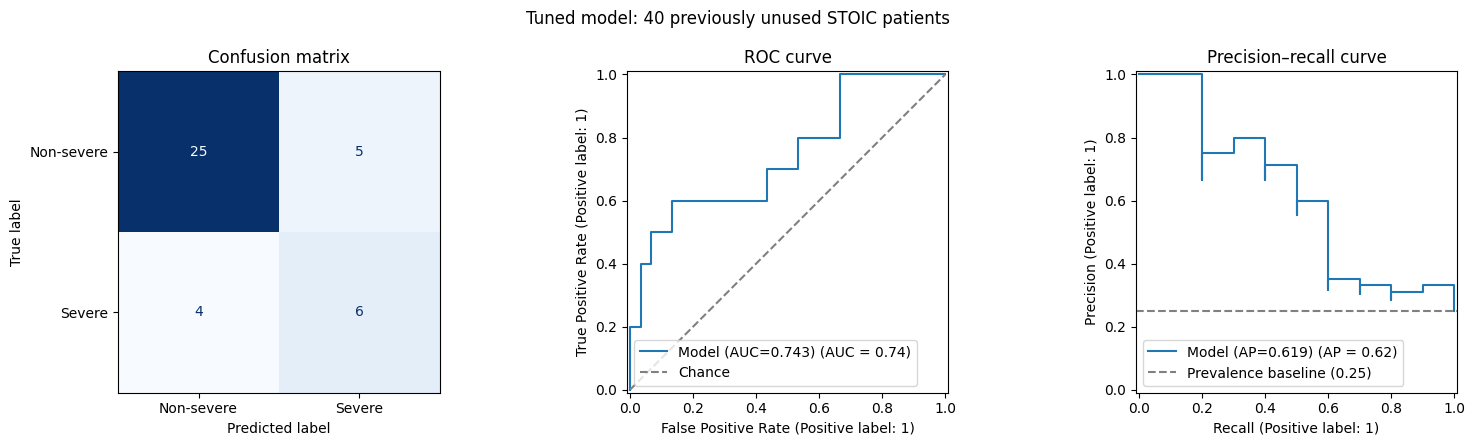

Saved: figures/evaluation_plots.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    roc_auc_score,
    average_precision_score
)

results = pd.read_csv(PROJECT / "evaluation_predictions.csv")
y = results["actual_severe"]
predictions = results["predicted_severe"]
scores = results["severity_score"]

FIGURES = PROJECT / "figures"
FIGURES.mkdir(exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

ConfusionMatrixDisplay.from_predictions(
    y, predictions,
    labels=[0, 1],
    display_labels=["Non-severe", "Severe"],
    cmap="Blues",
    colorbar=False,
    ax=axes[0]
)
axes[0].set_title("Confusion matrix")

RocCurveDisplay.from_predictions(
    y, scores,
    name=f"Model (AUC={roc_auc_score(y, scores):.3f})",
    ax=axes[1]
)
axes[1].plot([0, 1], [0, 1], "--", color="gray", label="Chance")
axes[1].legend()
axes[1].set_title("ROC curve")

PrecisionRecallDisplay.from_predictions(
    y, scores,
    name=f"Model (AP={average_precision_score(y, scores):.3f})",
    ax=axes[2]
)
axes[2].axhline(
    y.mean(), linestyle="--", color="gray",
    label=f"Prevalence baseline ({y.mean():.2f})"
)
axes[2].legend()
axes[2].set_title("Precision–recall curve")

fig.suptitle("Tuned model: 40 previously unused STOIC patients")
fig.tight_layout()
fig.savefig(FIGURES / "evaluation_plots.png", dpi=200,
            bbox_inches="tight")
plt.show()

print("Saved: figures/evaluation_plots.png")